In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Functional_Fusion.dataset import DataSetHcpTask, DataSetMDTB
import Functional_Fusion.atlas_map as am
# from IndividualParcellation.global_config import *
import OptimalBattery.scripts.hcp_task_covariance as sh
import os
import random
from scipy.stats import ttest_ind
import seaborn as sb


In [2]:
# Move this t oa untility function....
base_dir = 'Y:/data/FunctionalFusion/'
if not os.path.exists(base_dir):
    base_dir = '/cifs/diedrichsen/data/FunctionalFusion/'
if not os.path.exists(base_dir):
    base_dir = '/Volumes/diedrichsen_data$/data/FunctionalFusion_new'

fig_dir = '/Users/jdiedrichsen/Dropbox/papers/MultiTaskBattery_paper/Figures'

## Plot covariance matrics  and compute components

In [3]:
COV, tasks, infos = sh.get_covariance_matrices(space = 'fs32k',base_dir=base_dir)


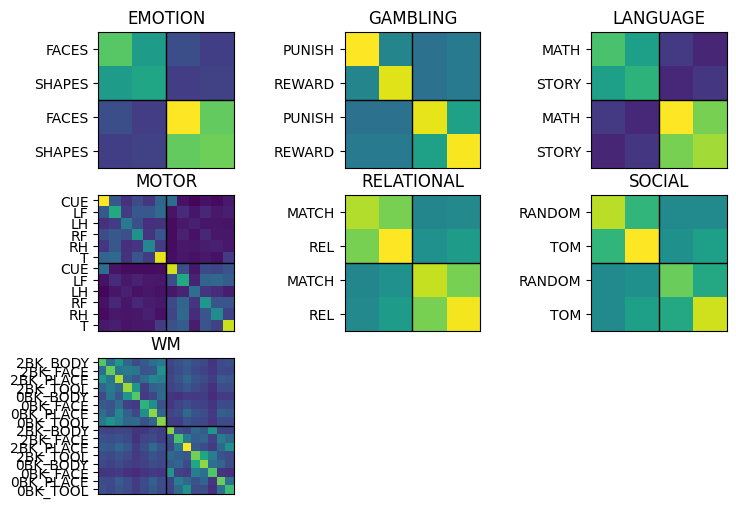

In [ ]:
plt.figure(figsize=(9,6))
sh.plot_all_covariances(COV,tasks,infos)
plt.savefig(fig_dir + '/hcp_task_covariances.pdf')

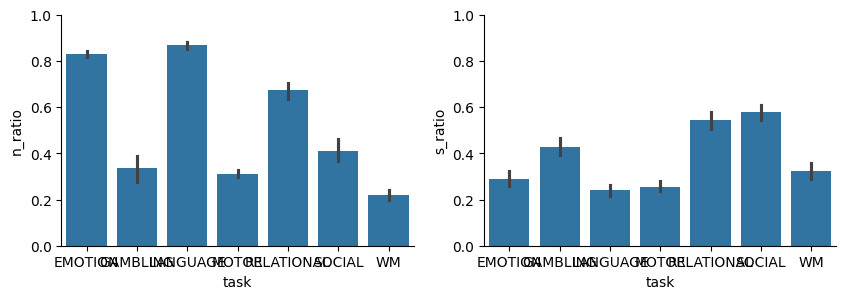

In [ ]:
plt.figure(figsize=(10,3))
D = sh.estimate_all_components(COV,tasks,infos)
D['n_ratio'] = D['noise_block'] / (D['noise']+D['noise_block'])
D['s_ratio'] = D['signal'] / (D['noise']+D['noise_block']+D['signal'])
plt.subplot(1,2,1)
ax=sb.barplot(D,x='task',y='n_ratio')
ax.set_ylim(0,1)
sb.despine()
plt.subplot(1,2,2)
ax=sb.barplot(D,x='task',y='s_ratio')
ax.set_ylim(0,1)
sb.despine()
plt.savefig(fig_dir + '/hcp_task_components.pdf')

In [6]:
pd.pivot_table(D, index='task', values=['n_ratio'], aggfunc=[np.mean,np.std])

/var/folders/2f/x5fxqvls6nv4ym5905k0s9vr0000gp/T/ipykernel_52011/2208252938.py:1: FutureWarning: The provided callable <function mean at 0x1074b6840> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pd.pivot_table(D, index='task', values=['n_ratio'], aggfunc=[np.mean,np.std])
/var/folders/2f/x5fxqvls6nv4ym5905k0s9vr0000gp/T/ipykernel_52011/2208252938.py:1: FutureWarning: The provided callable <function std at 0x1074b6980> is currently using DataFrameGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  pd.pivot_table(D, index='task', values=['n_ratio'], aggfunc=[np.mean,np.std])


,mean,std
,n_ratio,n_ratio
task,,
EMOTION,0.830814,0.048414
GAMBLING,0.335336,0.211636
LANGUAGE,0.867149,0.060911
MOTOR,0.311990,0.058245
RELATIONAL,0.673159,0.125053
SOCIAL,0.411350,0.183399
WM,0.221486,0.075919


# HCP Cov

In [7]:
HCP_dataset = DataSetHcpTask('Y:/data/FunctionalFusion/HCP_tfMRI')
if not os.path.exists('Y:/data/FunctionalFusion/HCP_tfMRI'):
    HCP_dataset = DataSetHcpTask('/cifs/diedrichsen/data/FunctionalFusion/HCP_tfMRI')

data_hcp , info_hcp= HCP_dataset.get_data(space=space,ses_id='ses-task',type = 'CondHalf')
# nans to zeros
data_hcp[np.isnan(data_hcp)] = 0


NameError: name 'space' is not defined

In [ ]:
def get_cov(data_hcp,info_hcp,task_name=['all']):
    # subset info file
    if task_name == ['all']:
        selected_info = info_hcp
    else:
        selected_info = info_hcp[info_hcp['task_name'].isin(task_name)]

    # subset data
    selected_info = selected_info.sort_values(by=["task_name", "half", "cond_name"])
    selected_indices = selected_info.index.tolist()
    selected_data_hcp = data_hcp[:, selected_indices, :]

    # get cov per subject
    subject_covariances = np.array([
        subject_data @ subject_data.T for subject_data in selected_data_hcp
    ])

    #avg cov matrix
    avg_cov_matrix = subject_covariances.mean(axis=0)

    # get the labels
    labels = (
        selected_info["cond_name"] +
        " (" + selected_info["task_name"] + "-Run" + selected_info["half"].astype(str) + ")"
    ).tolist()

    return avg_cov_matrix , labels

cov, labels = get_cov(data_hcp, info_hcp, task_name=['EMOTION', 'LANGUAGE'])

plt.figure(figsize=(6, 4))

symmetric_limit = max(abs(np.min(cov)), abs(np.max(cov)))
plt.imshow(cov, cmap='viridis', interpolation='nearest', vmin=-symmetric_limit, vmax=symmetric_limit)


tick_positions = np.arange(len(labels))
plt.xticks(tick_positions, labels, rotation=90, fontsize=8)
plt.yticks(tick_positions, labels, fontsize=8)

plt.colorbar(label='Covariance', ticks=np.linspace(-symmetric_limit, symmetric_limit, 5))




# MDTB realibility

In [ ]:
MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')
if not os.path.exists('Y:/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')

data_mdtb, mdtb_info = MDTB_dataset.get_data(space=space, ses_id='ses-s1', type='CondRun')


In [ ]:
def make_contrast(data, info, tasks, runs, subtract_rest=False):
    averaged_contrasts = []
    for task in tasks:
        task_contrasts = []
        for run in runs:
            run_info = info[info['run'] == run]
            task_idx = run_info[run_info['cond_name'] == task].index[0]
            if subtract_rest == True:
                rest_idx = run_info[run_info['cond_name'] == 'rest'].index[0]
                contrast = data[:, task_idx, :] - data[:, rest_idx, :]
            else:
                contrast = data[:, task_idx, :]
            task_contrasts.append(contrast)
        averaged_contrasts.append(np.mean(task_contrasts, axis=0))
    return np.stack(averaged_contrasts, axis=1)

def compute_reliability(data_half_1, data_half_2, contrast_indices=None):
    reliabilities = []
    all_subject_reliabilities = []

    if contrast_indices is not None:
        # Contrast-based reliability
        for idx_1, idx_2 in contrast_indices:
            contrast_half_1 = data_half_1[:, idx_1, :] - data_half_1[:, idx_2, :]
            contrast_half_2 = data_half_2[:, idx_1, :] - data_half_2[:, idx_2, :]

            flattened_half_1 = contrast_half_1.reshape(contrast_half_1.shape[0], -1)
            flattened_half_2 = contrast_half_2.reshape(contrast_half_2.shape[0], -1)

            subject_correlations = [
                np.corrcoef(flattened_half_1[i], flattened_half_2[i])[0, 1]
                for i in range(flattened_half_1.shape[0])
            ]

            reliabilities.append(np.mean(subject_correlations))
            all_subject_reliabilities.append(subject_correlations)
    else:
        # Direct condition-wise reliability
        for condition in range(data_half_1.shape[1]):
            condition_half_1 = data_half_1[:, condition, :]
            condition_half_2 = data_half_2[:, condition, :]

            subject_correlations = [
                np.corrcoef(condition_half_1[i], condition_half_2[i])[0, 1]
                for i in range(condition_half_1.shape[0])
            ]

            reliabilities.append(np.mean(subject_correlations))
            all_subject_reliabilities.append(subject_correlations)

    return reliabilities, all_subject_reliabilities


Build the Blocked design

In [ ]:
subtract_rest = True

In [ ]:
tasks = ["ToM", "MotorImagery"]
runs = range(1, 3)

contrasts_run_1_half_1 = make_contrast(data_mdtb, mdtb_info, tasks, runs,subtract_rest=subtract_rest)
contrasts_run_1_half_1.shape

In [ ]:
tasks = ['SpatialNavigation','FingerSeq']
runs = range(5, 7)

contrasts_run_2_half_1 = make_contrast(data_mdtb, mdtb_info, tasks, runs,subtract_rest=subtract_rest)
contrasts_run_2_half_1.shape

In [ ]:
tasks = ["ToM", "MotorImagery"]
runs = range(3, 5)

contrasts_run_1_half_2 = make_contrast(data_mdtb, mdtb_info, tasks, runs,subtract_rest=subtract_rest)
contrasts_run_1_half_2.shape

In [ ]:
tasks = ['SpatialNavigation','FingerSeq']
runs = range(7, 9)

contrasts_run_2_half_2 = make_contrast(data_mdtb, mdtb_info, tasks, runs,subtract_rest=subtract_rest)
contrasts_run_2_half_2.shape

In [ ]:
blocked_data_half_1 = np.concatenate([contrasts_run_1_half_1, contrasts_run_2_half_1], axis=1)
blocked_data_half_2 = np.concatenate([contrasts_run_1_half_2, contrasts_run_2_half_2], axis=1)

Build Interspersed design (conditions are against mean of all conds)

In [ ]:
conditions = ["ToM", "MotorImagery", "SpatialNavigation", "FingerSeq"]
runs = range(1, 3)
interspersed_data_half_1 = make_contrast(data_mdtb, mdtb_info, conditions, runs, subtract_rest=False)
interspersed_data_half_1.shape

In [ ]:
conditions = ["ToM", "MotorImagery", "SpatialNavigation", "FingerSeq"]
runs = range(3, 5)
interspersed_data_half_2 = make_contrast(data_mdtb, mdtb_info, conditions, runs, subtract_rest=False)
interspersed_data_half_2.shape


In [ ]:
# Nans to zeros
interspersed_data_half_1[np.isnan(interspersed_data_half_1)] = 0
interspersed_data_half_2[np.isnan(interspersed_data_half_2)] = 0
blocked_data_half_1[np.isnan(blocked_data_half_1)] = 0
blocked_data_half_2[np.isnan(blocked_data_half_2)] = 0


In [ ]:
# 3 types of contrasts
within_interspersed_indices = [(0, 1), (2, 3)]
between_interspersed_indices = [(0, 2), (0, 3), (1, 2), (1, 3)]
within_blocked_indices = [(0, 1), (2, 3)]
between_blocked_indices = [(0, 2), (0, 3), (1, 2), (1, 3)]

within_interspersed_reliability, within_interspersed_subjects = compute_reliability(interspersed_data_half_1, interspersed_data_half_2, within_interspersed_indices)
between_interspersed_reliability, between_interspersed_subjects = compute_reliability(interspersed_data_half_1, interspersed_data_half_2, between_interspersed_indices)
within_blocked_reliability, within_blocked_subjects = compute_reliability(blocked_data_half_1, blocked_data_half_2, within_blocked_indices)
between_blocked_reliability, between_blocked_subjects = compute_reliability(blocked_data_half_1, blocked_data_half_2, between_blocked_indices)

reliabilities = [
    np.mean(within_interspersed_reliability),
    np.mean(between_interspersed_reliability),
    np.mean(within_blocked_reliability),
    np.mean(between_blocked_reliability)
]

reliability_stds = [
    np.std(np.concatenate(within_interspersed_subjects)),
    np.std(np.concatenate(between_interspersed_subjects)),
    np.std(np.concatenate(within_blocked_subjects)),
    np.std(np.concatenate(between_blocked_subjects))
]

labels = ['Within Interspersed', 'Between Interspersed', 'Within Blocked', 'Between Blocked']

# Plot
plt.figure(figsize=(8, 6))
plt.bar(labels, reliabilities, yerr=reliability_stds, capsize=5, color=['orange', 'orange', 'blue', 'blue'])
plt.ylabel('Average Reliability')
plt.title('Reliability Comparison')
plt.tight_layout()
plt.show()


In [ ]:
# t-tests
stats_results = {}
stats_results['Within vs Between Interspersed'] = ttest_ind(
    np.concatenate(within_interspersed_subjects),
    np.concatenate(between_interspersed_subjects)
)
stats_results['Within Blocked vs Between Blocked'] = ttest_ind(
    np.concatenate(within_blocked_subjects),
    np.concatenate(between_blocked_subjects)
)
stats_results['Interspersed vs Blocked (Within)'] = ttest_ind(
    np.concatenate(within_interspersed_subjects),
    np.concatenate(within_blocked_subjects)
)
stats_results['Interspersed vs Blocked (Between)'] = ttest_ind(
    np.concatenate(between_interspersed_subjects),
    np.concatenate(between_blocked_subjects)
)

for comparison, result in stats_results.items():
    print(f"{comparison}: t-statistic = {result.statistic:.4f}, p-value = {result.pvalue:.4e}")

we basically gain power for the between task contrasts and we dont lose any power for the within task contrasts